In [5]:
import numpy as np
import matplotlib.pyplot as plt


def get_safe_ci(boot_angles, obs_mean, ci_level=95):
    centered = wrap_angle(boot_angles - obs_mean)
    lower_p = (100 - ci_level) / 2.0
    l_c, u_c = np.percentile(centered, [lower_p, 100 - lower_p])
    return wrap_angle(l_c + obs_mean), wrap_angle(u_c + obs_mean)


def wrap_angle(angle):
    """Bounds an angle between -pi and pi."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def circular_mean(angles):
    """Calculates the circular mean."""
    S = np.sum(np.sin(angles))
    C = np.sum(np.cos(angles))
    return np.arctan2(S, C)


def circular_comparison(phases1, phases2, n_iters=5000, ci_level=95, seed=42):
    """
    Bootstrap and permutation

    Parameters
    ----------
    phases1, phases2
        The phases of the two events in radians
    n_iters

    ci_level
    seed

    Returns
    -------

    """
    np.random.seed(seed)
    ph1 = np.asarray(phases1)
    ph2 = np.asarray(phases2)
    n1, n2 = len(ph1), len(ph2)

    # Calculate true observed means and difference
    obs_mean1 = circular_mean(ph1)
    obs_mean2 = circular_mean(ph2)
    obs_diff = wrap_angle(obs_mean1 - obs_mean2)

    # =========================================================
    #  THE BOOTSTRAP (Calculates the physical 95% CI)
    # =========================================================
    idxs1 = np.random.randint(0, n1, size=(n_iters, n1))
    idxs2 = np.random.randint(0, n2, size=(n_iters, n2))

    S1, C1 = np.sum(np.sin(ph1[idxs1]), axis=1), np.sum(np.cos(ph1[idxs1]), axis=1)
    S2, C2 = np.sum(np.sin(ph2[idxs2]), axis=1), np.sum(np.cos(ph2[idxs2]), axis=1)

    boot_means1 = np.arctan2(S1, C1)
    boot_means2 = np.arctan2(S2, C2)
    boot_diffs = wrap_angle(boot_means1 - boot_means2)

    # Calculate CIs for individual groups (for polar plot)
    lower1, upper1 = get_safe_ci(boot_means1, obs_mean1, ci_level=ci_level)
    lower2, upper2 = get_safe_ci(boot_means2, obs_mean2, ci_level=ci_level)

    # Calculate CI for the difference (for histogram/reporting)
    ci_lower, ci_upper = get_safe_ci(boot_diffs, obs_diff, ci_level=ci_level)

    # Permutation for p_val
    pool = np.concatenate([ph1, ph2])
    n_total = len(pool)

    shuffled_idxs = np.random.rand(n_iters, n_total).argsort(axis=1)
    shuffled_pool = pool[shuffled_idxs]

    pseudo1 = shuffled_pool[:, :n1]
    pseudo2 = shuffled_pool[:, n1:]

    S_p1, C_p1 = np.sum(np.sin(pseudo1), axis=1), np.sum(np.cos(pseudo1), axis=1)
    S_p2, C_p2 = np.sum(np.sin(pseudo2), axis=1), np.sum(np.cos(pseudo2), axis=1)

    perm_diffs = wrap_angle(np.arctan2(S_p1, C_p1) - np.arctan2(S_p2, C_p2))
    p_value = (np.sum(np.abs(perm_diffs) >= np.abs(obs_diff)) + 1) / (n_iters + 1)

    return {
        "observed_diff": obs_diff,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "p_value": p_value,
        "boot_diffs": boot_diffs,
        "perm_diffs": perm_diffs,
        "obs_mean1": obs_mean1,
        "lower1": lower1,
        "upper1": upper1,
        "obs_mean2": obs_mean2,
        "lower2": lower2,
        "upper2": upper2
    }

Observed Difference: -11.56°
95% CI: -15.95° to -7.39°
P-value: 0.0186


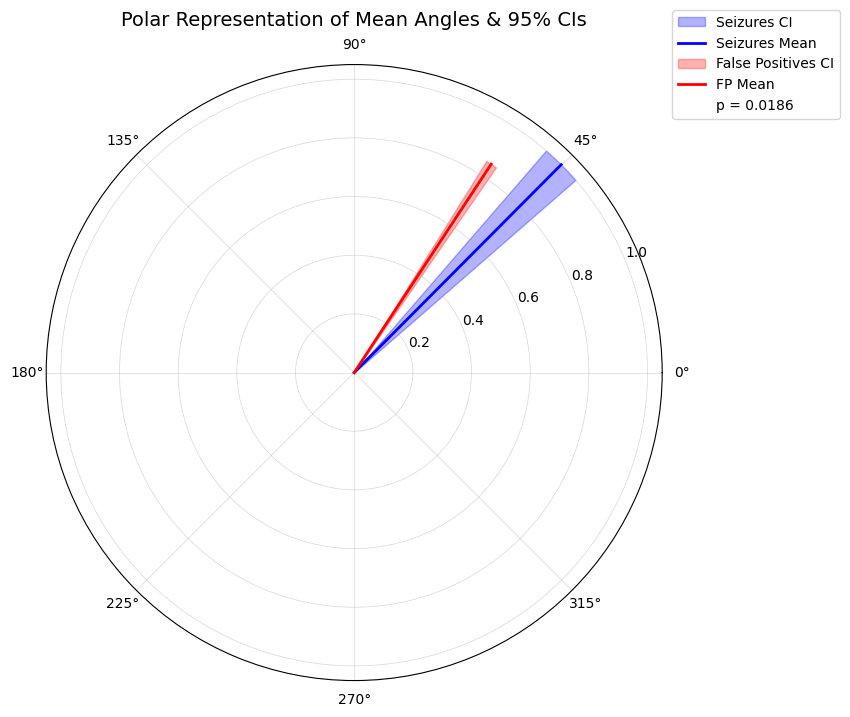

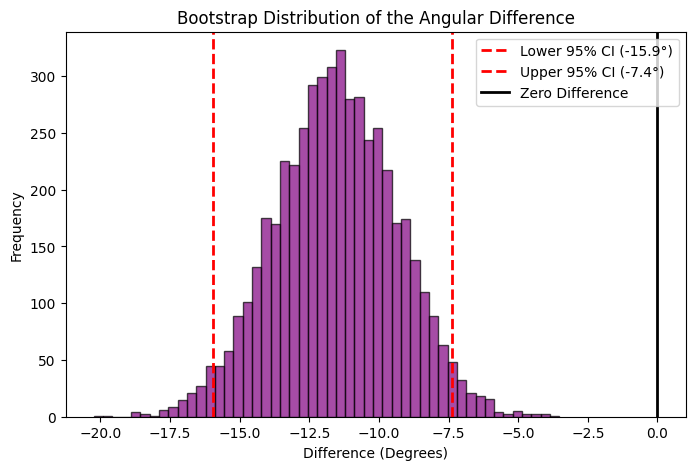

In [6]:
# =========================================================
# USAGE AND PLOTTING EXTRACTION
# =========================================================
# Generate Mock Data
np.random.seed(42)
true_seizures = np.random.vonmises(mu=np.pi / 4, kappa=5.0, size=150)
false_positives = np.random.vonmises(mu=np.pi / 4 + 0.2, kappa=1.5, size=8000)

results = circular_comparison(true_seizures, false_positives, n_iters=5000, ci_level=95, seed=42)

print(f"Observed Difference: {np.degrees(results['observed_diff']):.2f}°")
print(f"95% CI: {np.degrees(results['ci_lower']):.2f}° to {np.degrees(results['ci_upper']):.2f}°")
print(f"P-value: {results['p_value']:.4f}")

# 1. Extract plotting variables
boot_diffs = results["boot_diffs"]
szr_mean, szr_lower, szr_upper = results["obs_mean1"], results["lower1"], results["upper1"]
fp_mean, fp_lower, fp_upper = results["obs_mean2"], results["lower2"], results["upper2"]

# Grab the CI bounds for the difference to use in the histogram
diff_lower = results["ci_lower"]
diff_upper = results["ci_upper"]

# ==========================================
# PLOT 1: Polar Plot
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})


def make_arc(ax, lower, upper, radius, color, label, alpha=0.3):
    """Helper function to draw CI wedges on a polar plot."""
    if upper < lower:
        upper += 2 * np.pi
    theta = np.linspace(lower, upper, 200)
    ax.fill_between(theta, 0, radius, color=color, alpha=alpha, label=label)


# Plot Seizures (Outer Wedge)
make_arc(ax1, szr_lower, szr_upper, 1.0, 'blue', 'Seizures CI')
ax1.plot([0, szr_mean], [0, 1.0], color='blue', linewidth=2, label='Seizures Mean')

# Plot False Positives (Inner Wedge)
make_arc(ax1, fp_lower, fp_upper, 0.85, 'red', 'False Positives CI')
ax1.plot([0, fp_mean], [0, 0.85], color='red', linewidth=2, label='FP Mean')
ax1.plot([], [], label=f"p = {results['p_value']:.4f}", color='black', linestyle='None')

ax1.set_title('Polar Representation of Mean Angles & 95% CIs', va='bottom', fontsize=14)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# ==========================================
# PLOT 2: Histogram of the Difference
# ==========================================
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(np.degrees(boot_diffs), bins=50, color='purple', alpha=0.7, edgecolor='black')

# Using the correct bounds mapped from the results dictionary
ax2.axvline(np.degrees(diff_lower), color='red', linestyle='dashed', linewidth=2,
            label=f"Lower 95% CI ({np.degrees(diff_lower):.1f}°)")
ax2.axvline(np.degrees(diff_upper), color='red', linestyle='dashed', linewidth=2,
            label=f"Upper 95% CI ({np.degrees(diff_upper):.1f}°)")
ax2.axvline(0, color='black', linewidth=2, label='Zero Difference')

ax2.set_title('Bootstrap Distribution of the Angular Difference')
ax2.set_xlabel('Difference (Degrees)')
ax2.set_ylabel('Frequency')
ax2.legend()
plt.show()